In [1]:
# Task 3
# Workflow
# Use qc filtered dataset, compute hvg and select perturbations (all) present in 3 contitions with > 20 cells present each perturbation
# Select 50 perturbations regarding pathway information

In [11]:
# import packages
import scanpy as sc
import numpy as np
import pandas as pd

In [12]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [13]:
#Print the column names
print(adata.obs.columns)

Index(['library_preparation_protocol', 'condition', 'MOI', 'sgRNA',
       'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer',
       'disease', 'perturbation_type', 'celltype', 'organism',
       'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito',
       'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts',
       'doublet_scores', 'predicted_doublets', 'doublet_info'],
      dtype='str')


In [15]:
#Check the distribution of cells across the Control, IFNγ, and Co-culture conditions
print(adata.obs["condition"].value_counts())

condition
IFNγ          75046
Co-culture    68937
Control       49875
Name: count, dtype: int64


In [21]:
# Define the variables
RANDOM_STATE = 42
MIN_CELLS = 20
N_PERTURBATIONS = 50
N_TEST = 10
N_HVG = 2000
PERT_COL = "perturbation"
COND_COL = "condition"
CONDITIONS = ["Control", "IFNγ", "Co-culture"]

In [23]:
# Cell counts for perturbation x condition
counts = (
    adata.obs
    .groupby([PERT_COL, COND_COL], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Keep only the conditions to use
available_conditions = [
    c for c in CONDITIONS
    if c in counts.columns
]

print("Available conditions:", available_conditions)

# Keep perturbations with >= MIN_CELLS in every condition
eligible = counts[
    (counts[available_conditions] >= MIN_CELLS).all(axis=1)
].index.tolist()

print("Eligible perturbations:", len(eligible))

Available conditions: ['Control', 'IFNγ', 'Co-culture']
Eligible perturbations: 233


In [25]:
# Define possible labels used for unperturbed or non-targeting control cells
CONTROL_NAMES = {
    "control",
    "ctrl",
    "nt",
    "ntc",
    "non-targeting",
    "nontargeting",
    "non_targeting"
}

# Remove control/non-targeting labels from the list of eligible perturbations,
# since only actual gene perturbations should be considered for the 50-gene selection
eligible = [
    gene for gene in eligible
    if str(gene).lower() not in CONTROL_NAMES
]

# Display the number of eligible gene perturbations remaining after control removal
print("Eligible real perturbations:", len(eligible))

Eligible real perturbations: 232


In [26]:
import sys
!{sys.executable} -m pip install gseapy

In [27]:
import gseapy as gp
print(gp.__version__)

1.3.1


In [28]:
#Download Hallmark pathway annotations
import gseapy as gp
hallmark = gp.get_library(
    name="MSigDB_Hallmark_2020",
    organism="Human"
)
print("Number of pathways:", len(hallmark))

Number of pathways: 50


In [29]:
# Convert all gene names in the Hallmark pathway dictionary to uppercase
# to ensure consistent gene-name matching regardless of capitalization
hallmark_upper = {
    pathway: {str(g).upper() for g in genes}
    for pathway, genes in hallmark.items()
}

In [30]:
import pandas as pd

# Create a dictionary mapping each eligible perturbation gene
# to its uppercase version for consistent matching with Hallmark gene names
eligible_upper = {
    gene: str(gene).upper()
    for gene in eligible
}

# Initialize a binary pathway-membership matrix:
# rows = eligible perturbation genes
# columns = Hallmark pathways
# 0 = gene is not part of the pathway
# 1 = gene is part of the pathway
pathway_matrix = pd.DataFrame(
    0,
    index=eligible,
    columns=hallmark_upper.keys(),
    dtype=int
)

# Check each eligible perturbation gene against every Hallmark pathway
for gene in eligible:

    # Retrieve the uppercase version of the perturbation gene
    gene_upper = eligible_upper[gene]

    for pathway, pathway_genes in hallmark_upper.items():

        # Mark the gene as 1 if it belongs to the corresponding Hallmark pathway
        if gene_upper in pathway_genes:
            pathway_matrix.loc[gene, pathway] = 1

In [31]:
# Display the dimensions of the pathway-membership matrix
# (number of eligible perturbation genes × number of Hallmark pathways)
print(pathway_matrix.shape)

# Display the first five perturbation genes and their binary pathway memberships
# to verify that the pathway annotation matrix was constructed correctly
pathway_matrix.head()

(232, 50)


,TNF-alpha Signaling via NF-kB,Hypoxia,Cholesterol Homeostasis,Mitotic Spindle,Wnt-beta Catenin Signaling,TGF-beta Signaling,IL-6/JAK/STAT3 Signaling,DNA Repair,G2-M Checkpoint,Apoptosis,...,heme Metabolism,Coagulation,IL-2/STAT5 Signaling,Bile Acid Metabolism,Pperoxisome,Allograft Rejection,Spermatogenesis,KRAS Signaling Up,KRAS Signaling Dn,Pancreas Beta Cells
A2M,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
ACSL3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ACTA2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AEBP1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AGA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
#Count how many Hallmark pathways annotate each perturbation:
gene_pathway_count = pathway_matrix.sum(axis=1)
gene_pathway_count.sort_values(
    ascending=False
).head(20)

CDKN1A    10
MYC       10
CD44       8
CCND1      7
TIMP1      7
TGFB1      7
CCND2      7
FOS        6
IFNGR2     5
KLF4       5
SAT1       5
NOLC1      5
JAK2       5
CDK4       5
CXCR4      5
IFNGR1     5
MDH2       4
IDH2       4
FKBP4      4
GSN        4
dtype: int64

In [33]:
#how many eligible perturbations are represented in each pathway:
pathway_gene_count = pathway_matrix.sum(axis=0)
pathway_gene_count.sort_values(
    ascending=False
)

Myc Targets V1                       16
E2F Targets                          15
Allograft Rejection                  15
Interferon Gamma Response            14
p53 Pathway                          14
Estrogen Response Late               13
Apoptosis                            13
G2-M Checkpoint                      12
KRAS Signaling Up                    12
Complement                           12
Epithelial Mesenchymal Transition    10
TNF-alpha Signaling via NF-kB        10
IL-2/STAT5 Signaling                 10
mTORC1 Signaling                      9
Coagulation                           9
Glycolysis                            9
Estrogen Response Early               8
Oxidative Phosphorylation             8
Myogenesis                            7
IL-6/JAK/STAT3 Signaling              7
Adipogenesis                          7
Androgen Response                     7
Hypoxia                               7
Xenobiotic Metabolism                 7
Inflammatory Response                 7


In [34]:
#check genes with no Hallmark annotation
no_pathway = pathway_matrix.index[
    pathway_matrix.sum(axis=1) == 0
].tolist()

print("Eligible genes without Hallmark annotation:")
print(no_pathway)

print(
    "Annotated:",
    len(eligible) - len(no_pathway),
    "/",
    len(eligible)
)

Eligible genes without Hallmark annotation:
['AGA', 'ARMC6', 'ATP5MD', 'BOLA2B', 'BZW2', 'C6orf226', 'C19orf48', 'CCR10', 'CD58', 'CDC123', 'CDH19', 'CGAS', 'CHCHD2', 'CITED1', 'CMSS1', 'CSPG4', 'CST3', 'CTSA', 'DAG1', 'DDR1', 'DDX17', 'DLL3', 'EEA1', 'EEF1G', 'EIF3K', 'EVA1A', 'FBXO32', 'FMN1', 'FOXM1', 'FRZB', 'FTH1', 'GAS5', 'GPATCH4', 'GRN', 'GSEC', 'HASPIN', 'HLA-DRB5', 'HLA-H', 'IDI2-AS1', 'IRF3', 'ISYNA1', 'JMJD7', 'KDR', 'LEF1-AS1', 'LINC00518', 'LRRC75A-AS1', 'MC1R', 'MFGE8', 'MIA', 'MRPL47', 'NDUFA13', 'NEAT1', 'NGFR', 'NMRK1', 'NONO', 'NPC2', 'NSG1', 'NUP50-AS1', 'PET100', 'PFDN4', 'PIK3IP1', 'PSAP', 'PSMB8-AS1', 'PTMA', 'PUF60', 'RBP7', 'ROMO1', 'RPSA', 'RRS1', 'S100A6', 'S100B', 'SAE1', 'SCARB2', 'SEC11C', 'SERPINF1', 'SINHCAF', 'SLC5A3', 'SLC7A5P1', 'SLIRP', 'SMAD4', 'SNHG6', 'SOX4', 'SP100', 'SPESP1', 'SPINT1', 'SSR2', 'ST3GAL6-AS1', 'TAPBPL', 'TFAP2A', 'TMEM173', 'TOP1MT', 'TPP1', 'TRIM22', 'TSC22D3', 'TTLL1', 'TXNDC17', 'UCN2', 'VAT1', 'WBP2', 'XAGE1A']
Annotated: 132 

In [35]:
# Select 50 perturbations that maximize pathway coverage
# 134 from 234 perturbations are annotated to one pathway
import numpy as np
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[
    pathway_matrix.sum(axis=1) > 0
].tolist()
selected_50 = []
covered_pathways = set()
remaining = annotated_genes.copy()

In [36]:
# Iteratively select perturbation genes until 50 genes have been chosen
# or no eligible genes remain
while len(selected_50) < 50 and len(remaining) > 0:

    # Store how many previously uncovered pathways each remaining gene would add
    gains = {}

    for gene in remaining:

        # Identify all Hallmark pathways associated with the current gene
        gene_pathways = set(
            pathway_matrix.columns[
                pathway_matrix.loc[gene] == 1
            ]
        )

        # Determine which of these pathways have not yet been represented
        # by the already selected perturbations
        new_pathways = gene_pathways - covered_pathways

        # Record the number of new pathways that this gene would contribute
        gains[gene] = len(new_pathways)

    # Find the largest number of new pathways contributed by any remaining gene
    max_gain = max(gains.values())

    # Identify all genes that provide the maximum additional pathway coverage
    best_genes = [
        gene for gene, gain in gains.items()
        if gain == max_gain
    ]

    # Randomly choose one gene if several genes provide the same maximum gain
    # (using the predefined random generator for reproducibility)
    chosen = rng.choice(best_genes)

    # Add the selected gene to the final set of perturbations
    selected_50.append(chosen)

    # Retrieve all Hallmark pathways associated with the newly selected gene
    gene_pathways = set(
        pathway_matrix.columns[
            pathway_matrix.loc[chosen] == 1
        ]
    )

    # Update the set of pathways already represented by the selected genes
    covered_pathways.update(gene_pathways)

    # Remove the selected gene so that it cannot be selected again
    remaining.remove(chosen)

In [37]:
# If the pathway-based selection produced fewer than 50 perturbations,
# fill the remaining positions with other eligible perturbation genes
if len(selected_50) < 50:

    # Identify eligible genes that have not already been selected
    remaining_eligible = [
        gene for gene in eligible
        if gene not in selected_50
    ]

    # Randomly select enough additional genes to reach a total of 50
    # without selecting the same gene more than once
    extra = rng.choice(
        remaining_eligible,
        size=50 - len(selected_50),
        replace=False
    )

    # Add the randomly selected genes to the final perturbation set
    selected_50.extend(extra.tolist())

In [38]:
#Show selected perturbations and hallmark pathways represented
print("Selected perturbations:", len(selected_50))

print(
    "Hallmark pathways represented:",
    pathway_matrix.loc[selected_50]
    .max(axis=0)
    .sum()
)

Selected perturbations: 50
Hallmark pathways represented: 46


In [39]:
# Count how many of the 50 selected perturbation genes are associated
# with each Hallmark pathway
selected_pathway_counts = (
    pathway_matrix
    .loc[selected_50]             # Keep only the 50 selected perturbation genes
    .sum(axis=0)                  # Count pathway memberships across these genes
    .sort_values(ascending=False) # Sort pathways from most to least represented
)

# Display only Hallmark pathways represented by at least one
# of the 50 selected perturbation genes
selected_pathway_counts[
    selected_pathway_counts > 0
]

Apoptosis                            8
G2-M Checkpoint                      7
E2F Targets                          7
Complement                           7
TNF-alpha Signaling via NF-kB        6
Myogenesis                           5
Interferon Gamma Response            5
Myc Targets V1                       5
Estrogen Response Late               5
Allograft Rejection                  5
p53 Pathway                          5
Coagulation                          5
KRAS Signaling Up                    5
Hypoxia                              4
Oxidative Phosphorylation            4
Inflammatory Response                4
Adipogenesis                         3
Androgen Response                    3
IL-6/JAK/STAT3 Signaling             3
Wnt-beta Catenin Signaling           3
IL-2/STAT5 Signaling                 3
Angiogenesis                         3
mTORC1 Signaling                     3
Myc Targets V2                       3
Estrogen Response Early              2
Protein Secretion        

In [40]:
# Initialize the list of perturbation genes that will be held out for testing
# and a set to keep track of the Hallmark pathways already represented in the test set
test_genes = []
covered_test_pathways = set()

# Start with all 50 selected perturbation genes as possible test candidates
remaining = selected_50.copy()

# Iteratively select 10 held-out test perturbations
# while maximizing pathway diversity in the test set
while len(test_genes) < 10:

    # Store how many previously uncovered pathways each candidate gene would add
    gains = {}

    for gene in remaining:

        # Identify all Hallmark pathways associated with the current gene
        gene_pathways = set(
            pathway_matrix.columns[
                pathway_matrix.loc[gene] == 1
            ]
        )

        # Calculate how many new pathways this gene would contribute
        # compared with pathways already represented in the test set
        gains[gene] = len(
            gene_pathways - covered_test_pathways
        )

    # Find the maximum number of new pathways contributed by any remaining gene
    max_gain = max(gains.values())

    # Identify all genes that provide the maximum additional pathway coverage
    candidates = [
        gene for gene, gain in gains.items()
        if gain == max_gain
    ]

    # If several genes provide the same pathway gain, randomly select one
    # using the predefined random generator for reproducibility
    chosen = rng.choice(candidates)

    # Add the selected perturbation gene to the held-out test set
    test_genes.append(chosen)

    # Update the set of Hallmark pathways represented by the test genes
    covered_test_pathways.update(
        pathway_matrix.columns[
            pathway_matrix.loc[chosen] == 1
        ]
    )

    # Remove the selected gene from the candidate pool
    # so that it cannot be selected again
    remaining.remove(chosen)

In [41]:
# Create the training set by selecting all genes from the 50 selected perturbations
# that were not assigned to the held-out test set
train_genes = [
    gene for gene in selected_50
    if gene not in test_genes
]

# Check that the final split contains 40 training perturbations
# and 10 completely held-out test perturbations
print("Train:", len(train_genes))
print("Test:", len(test_genes))

# Display the perturbation genes that will be used for model training
print("\nTrain genes:")
print(train_genes)

# Display the perturbation genes that will remain completely unseen during
# model training and hyperparameter optimization and will only be used for final testing
print("\nHeld-out test genes:")
print(test_genes)

Train: 40
Test: 10

Train genes:
[np.str_('SGK1'), np.str_('BOLA2'), np.str_('MT2A'), np.str_('HLA-C'), np.str_('SDC3'), np.str_('HLA-F'), np.str_('GSN'), np.str_('NOLC1'), np.str_('CCND1'), np.str_('KCNN4'), np.str_('CD59'), np.str_('STAT3'), np.str_('IFNGR1'), np.str_('JPT1'), np.str_('GAA'), np.str_('CDKN2B'), np.str_('TP53'), np.str_('SLC19A1'), np.str_('PPA1'), np.str_('HLA-A'), np.str_('SMAD3'), np.str_('LY96'), np.str_('HNRNPC'), np.str_('HSPA1A'), np.str_('CTSB'), np.str_('ATP1B1'), np.str_('NPC1'), np.str_('TIMP2'), np.str_('APOC2'), np.str_('STX7'), np.str_('ST6GALNAC2'), np.str_('DDX39A'), np.str_('POLD2'), np.str_('CD274'), np.str_('SERPINA3'), np.str_('RB1'), np.str_('FGFR1'), np.str_('APOD'), np.str_('UQCRH'), np.str_('HNRNPA1')]

Held-out test genes:
[np.str_('MYC'), np.str_('CDKN1A'), np.str_('TIMP1'), np.str_('IDH2'), np.str_('MDH2'), np.str_('CDK6'), np.str_('LAMP2'), np.str_('IFNGR2'), np.str_('CCND2'), np.str_('LGALS3')]


In [42]:
# Determine which Hallmark pathways are represented by at least one
# perturbation gene in the training set
train_coverage = (
    pathway_matrix
    .loc[train_genes]  # Keep only the 40 training perturbations
    .max(axis=0)       # 1 if at least one training gene belongs to the pathway
)

# Determine which Hallmark pathways are represented by at least one
# perturbation gene in the held-out test set
test_coverage = (
    pathway_matrix
    .loc[test_genes]   # Keep only the 10 held-out perturbations
    .max(axis=0)       # 1 if at least one test gene belongs to the pathway
)

# Count the total number of Hallmark pathways represented
# among the training perturbations
print(
    "Pathways represented in train:",
    int(train_coverage.sum())
)

# Count the total number of Hallmark pathways represented
# among the held-out test perturbations
print(
    "Pathways represented in test:",
    int(test_coverage.sum())
)

Pathways represented in train: 40
Pathways represented in test: 37


In [43]:
# Identify the Hallmark pathways represented by at least one of the 10 held-out test perturbation genes
test_pathways = test_coverage[
    test_coverage == 1
].index.tolist()

# Display the list of Hallmark pathways represented in the test set
print(test_pathways)

['TNF-alpha Signaling via NF-kB', 'Hypoxia', 'Cholesterol Homeostasis', 'Wnt-beta Catenin Signaling', 'TGF-beta Signaling', 'IL-6/JAK/STAT3 Signaling', 'G2-M Checkpoint', 'Apoptosis', 'Adipogenesis', 'Estrogen Response Early', 'Estrogen Response Late', 'Androgen Response', 'Myogenesis', 'Protein Secretion', 'Interferon Gamma Response', 'Hedgehog Signaling', 'Complement', 'PI3K/AKT/mTOR  Signaling', 'mTORC1 Signaling', 'E2F Targets', 'Myc Targets V1', 'Myc Targets V2', 'Epithelial Mesenchymal Transition', 'Inflammatory Response', 'Fatty Acid Metabolism', 'Oxidative Phosphorylation', 'Glycolysis', 'p53 Pathway', 'UV Response Dn', 'Angiogenesis', 'heme Metabolism', 'Coagulation', 'IL-2/STAT5 Signaling', 'Bile Acid Metabolism', 'Pperoxisome', 'Allograft Rejection', 'KRAS Signaling Up']


In [44]:
# Compute highly variable genes (HVGs) to define a reduced set of
# informative genes used as the transcriptomic response variables

import scanpy as sc
import numpy as np
from scipy import sparse

# Create a copy of the original AnnData object so that normalization
# and log transformation for HVG selection do not modify the original data
adata_hvg = adata.copy()

# Normalize gene-expression counts so that each cell has the same
# total expression count (10,000 counts per cell)
sc.pp.normalize_total(
    adata_hvg,
    target_sum=1e4
)

# Apply a log(1+x) transformation to the normalized expression values
# before identifying highly variable genes
sc.pp.log1p(adata_hvg)

# Identify the 2,000 genes showing the highest variability across cells
sc.pp.highly_variable_genes(
    adata_hvg,
    n_top_genes=2000
)

# Extract the names of the 2,000 selected highly variable genes
# that will be used to represent the transcriptomic response
response_hvgs = adata_hvg.var_names[
    adata_hvg.var["highly_variable"]
].tolist()

# Verify that 2,000 HVGs were selected and display the first 20 genes
print("Number of HVGs:", len(response_hvgs))
print(response_hvgs[:20])

Number of HVGs: 2000
['AADAC', 'AATBC', 'ABCB11', 'ABCB6', 'ABHD12B', 'ABL2', 'AC002310.2', 'AC002347.1', 'AC002384.1', 'AC003092.1', 'AC003956.1', 'AC004112.1', 'AC004231.1', 'AC004232.2', 'AC004448.2', 'AC004471.2', 'AC004528.1', 'AC004584.1', 'AC004771.4', 'AC004771.5']


In [45]:
# Use the 2,000 selected highly variable genes as the response genes
# whose mean log2 fold-change values will be predicted by the models
response_genes = response_hvgs

In [66]:
import numpy as np
from scipy import sparse

# Small constant added when calculating log2 fold changes later
# to avoid division by zero
PSEUDOCOUNT = 1


# Define a function to calculate the mean expression of the selected
# response genes across all cells in an AnnData subset
def mean_expression(adata_subset, genes):

    # Extract the expression matrix for the selected response genes
    X = adata_subset[:, genes].X

    # Calculate the mean expression of each gene across all cells
    if sparse.issparse(X):
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()
    else:
        mean = np.asarray(
            X.mean(axis=0)
        ).ravel()

    # Return one mean expression value for each response gene
    return mean

In [67]:
# Display the 20 most frequent perturbation targets
# and the number of cells associated with each perturbation
print(
    adata.obs[PERT_COL]
    .value_counts()
    .head(20)
)

perturbation
control     50516
ACTA2        1241
B2M          1169
A2M          1121
AEBP1        1116
IFNGR2       1106
CTSD         1084
CD59         1066
CD44         1061
CD274        1060
FGFR1        1051
JAK2         1030
CDH19        1028
CSPG4        1025
CD58         1018
C19orf48      977
APOC2         968
ATP1B1        965
AGA           963
APOE          954
Name: count, dtype: int64


In [68]:
# Define the label used to identify unperturbed/control cells
# in the perturbation column
UNPERTURBED_LABEL = "control"

# Define the three experimental conditions included in the analysis
CONDITIONS = ["Control", "IFNγ", "Co-culture"]

# Define the AnnData observation column containing the
# CRISPR perturbation target for each cell
PERT_COL = "perturbation"

# Define the AnnData observation column containing the
# experimental condition for each cell
COND_COL = "condition"

In [69]:
# Create a Boolean mask to identify unperturbed/control cells
baseline_means = {}

for condition in adata.obs[COND_COL].unique():

    # Select unperturbed/control cells within the current condition
    baseline_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    # Subset baseline cells
    baseline_adata = adata[baseline_mask]

    # Calculate mean expression of the response genes
    baseline_means[condition] = mean_expression(
        baseline_adata,
        response_genes
    )

    print(
        condition,
        "baseline cells:",
        baseline_mask.sum()
    )

Control baseline cells: 12938
IFNγ baseline cells: 20396
Co-culture baseline cells: 17182


In [71]:
from scipy import sparse
import numpy as np

# Access the gene-expression matrix from the AnnData object
X = adata.X

# Extract the stored expression values depending on whether
# the expression matrix is sparse or dense
if sparse.issparse(X):
    values = X.data
else:
    values = np.asarray(X).ravel()

# Check the expression matrix for missing (NaN) or infinite values
# and inspect its numerical range
print("NaN:", np.isnan(values).sum())
print("Inf:", np.isinf(values).sum())
print("Min:", np.nanmin(values))
print("Max:", np.nanmax(values))

# Display the first 20 stored expression values to inspect
# the scale and format of the expression data
print("First values:")
print(values[:20])

NaN: 0
Inf: 0
Min: 1.0
Max: 4437.0
First values:
[2. 1. 1. 1. 1. 2. 1. 1. 2. 2. 1. 1. 2. 5. 1. 1. 1. 1. 2. 1.]


In [73]:
# Initialize a list to store the condition-specific
# transcriptional response profiles for the 50 selected perturbations
profiles = []

# Loop through the three experimental conditions
for condition in CONDITIONS:

    # Identify unperturbed/control cells within the current condition
    baseline_mask = (
        (adata.obs[COND_COL] == condition)
        &
        (
            adata.obs[PERT_COL]
            .astype(str)
            .str.lower()
            == UNPERTURBED_LABEL.lower()
        )
    )

    # Extract the condition-matched unperturbed cells
    baseline_adata = adata[baseline_mask]

    # Display the number of baseline cells available
    # for the current experimental condition
    print(
        condition,
        "baseline cells:",
        baseline_adata.n_obs
    )

    # Calculate the mean expression of the 2,000 response genes
    # in the unperturbed cells of the current condition
    baseline_mean = mean_expression(
        baseline_adata,
        response_genes
    )

    # Loop through each of the 50 selected perturbation targets
    for pert in selected_50:

        # Identify cells carrying the current perturbation
        # within the current experimental condition
        pert_mask = (
            (adata.obs[COND_COL] == condition)
            &
            (adata.obs[PERT_COL] == pert)
        )

        # Extract the corresponding perturbed cells
        pert_adata = adata[pert_mask]

        # Skip perturbation-condition combinations with fewer
        # than the minimum required number of cells
        if pert_adata.n_obs < MIN_CELLS:
            continue

        # Calculate the mean expression of the 2,000 response genes
        # for the current perturbation-condition combination
        pert_mean = mean_expression(
            pert_adata,
            response_genes
        )

        # Calculate the mean log2 fold change for each response gene
        # relative to the condition-matched unperturbed baseline.
        # The pseudocount prevents division by zero.
        log2fc = np.log2(
            (pert_mean + PSEUDOCOUNT)
            /
            (baseline_mean + PSEUDOCOUNT)
        )

        # Store the perturbation name, experimental condition,
        # number of cells, and 2,000-gene log2FC response vector
        profiles.append({
            "perturbation": pert,
            "condition": condition,
            "n_cells": pert_adata.n_obs,
            "log2fc": log2fc
        })

Control baseline cells: 12938
IFNγ baseline cells: 20396
Co-culture baseline cells: 17182


In [74]:
# 3. Check number of profiles
print("Number of profiles:", len(profiles))

Number of profiles: 150


In [75]:
# Construct the target matrix Y containing the transcriptomic
# response (mean log2 fold change) for each perturbation-condition profile

import pandas as pd

# Create a metadata table describing each response profile.
# Each row corresponds to one perturbation under one experimental condition
# and stores the perturbation target, condition, and number of cells used.
profile_metadata = pd.DataFrame([
    {
        "perturbation": p["perturbation"],
        "condition": p["condition"],
        "n_cells": p["n_cells"]
    }
    for p in profiles
])

# Stack the log2FC response vectors into a single target matrix.
# Rows correspond to perturbation-condition profiles,
# while columns correspond to the 2,000 selected HVGs.
Y = np.vstack([
    p["log2fc"]
    for p in profiles
])

# Check the dimensions of the metadata table and target matrix.
# With 50 perturbations × 3 conditions, 150 profiles are expected.
# Y should therefore have 150 rows and 2,000 response genes.
print("Metadata:", profile_metadata.shape)
print("Target Y:", Y.shape)

Metadata: (150, 3)
Target Y: (150, 2000)


In [77]:
# Initialize a list that will store the input feature vector
# for each perturbation-condition profile
X_rows = []

# Loop through each row of the profile metadata table
for _, row in profile_metadata.iterrows():

    # Get the perturbation target gene for the current profile
    gene = row["perturbation"]

    # Get the experimental condition for the current profile
    condition = row["condition"]

    # Retrieve the Hallmark pathway membership features
    # of the current perturbation gene
    features = pathway_matrix.loc[gene].copy()

    # Add the experimental condition as one-hot encoded features.
    # Exactly one of these three variables will be equal to 1.
    features["condition_Control"] = int(
        condition == "Control"
    )

    features["condition_IFNγ"] = int(
        condition == "IFNγ"
    )

    features["condition_Co-culture"] = int(
        condition == "Co-culture"
    )

    # Add the complete feature vector for this
    # perturbation-condition profile to the input list
    X_rows.append(features)


# Convert the list of feature vectors into the final input matrix X.
# Rows = perturbation-condition profiles
# Columns = Hallmark pathway features + experimental condition features
X = pd.DataFrame(
    X_rows
).reset_index(drop=True)

# Check that the input and target matrices contain
# the same number of perturbation-condition profiles
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (150, 53)
Y shape: (150, 2000)


In [78]:
# Create Boolean masks that identify profiles belonging to the
# 40 training perturbations and the 10 held-out test perturbations
train_mask = profile_metadata["perturbation"].isin(train_genes)
test_mask = profile_metadata["perturbation"].isin(test_genes)


# Split the input feature matrix X according to the perturbation-level split.
# X_train contains pathway + condition features for the training perturbations,
# while X_test contains the same features for the unseen test perturbations.
X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)


# Split the target matrix Y using the same masks.
# Each row contains the 2,000-gene log2FC response for the corresponding
# perturbation-condition profile.
Y_train = Y[train_mask.values]
Y_test = Y[test_mask.values]


# Keep the corresponding metadata for the training profiles.
# This is particularly useful later for GroupKFold, where perturbation
# target will be used as the grouping variable.
meta_train = profile_metadata.loc[
    train_mask
].reset_index(drop=True)


# Keep the metadata for the held-out test profiles for later
# evaluation by perturbation and experimental condition.
meta_test = profile_metadata.loc[
    test_mask
].reset_index(drop=True)


# Display the dimensions of the training input and target matrices.
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

# Display the dimensions of the held-out test input and target matrices.
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (120, 53)
Y_train: (120, 2000)
X_test: (30, 53)
Y_test: (30, 2000)


In [79]:
# Check that no perturbation gene appears in both the training
# and held-out test sets, ensuring a strict perturbation-level split
print(
    "Overlap:",
    set(meta_train["perturbation"])
    &
    set(meta_test["perturbation"])
)

Overlap: set()


In [80]:
# Extract the Hallmark pathway-membership information
# for the 50 selected perturbation genes
selected_pathway_matrix = pathway_matrix.loc[selected_50]

# Identify selected perturbation genes that are not annotated
# to any of the Hallmark pathways.
# A row sum of 0 means that the gene has no Hallmark pathway membership.
zero_pathway_genes = selected_pathway_matrix.index[
    selected_pathway_matrix.sum(axis=1) == 0
].tolist()

# Display the selected perturbations for which no
# Hallmark pathway annotation was found
print(
    "Selected genes without Hallmark annotation:",
    zero_pathway_genes
)

Selected genes without Hallmark annotation: []


In [81]:
from sklearn.decomposition import PCA

# Define the number of principal components used to represent
# the 2,000-dimensional transcriptomic response
N_PCS = 50

# Initialize PCA to reduce the dimensionality of the target matrix Y
# from 2,000 gene-level log2FC values to 50 principal components
pca_y = PCA(
    n_components=N_PCS,
    random_state=42
)

# Fit PCA only on the training response profiles and transform
# Y_train into the 50-dimensional PCA representation.
# The test data are not used to learn the PCA components,
# preventing information leakage.
Y_train_pca = pca_y.fit_transform(Y_train)

# Project the held-out test response profiles onto the PCA space
# learned exclusively from the training data
Y_test_pca = pca_y.transform(Y_test)

# Display the dimensions before and after PCA transformation
print("Original Y_train:", Y_train.shape)
print("PCA Y_train:", Y_train_pca.shape)

# Calculate the total proportion of variance in the original
# 2,000-gene response profiles retained by the 50 PCs
print(
    "Variance explained:",
    pca_y.explained_variance_ratio_.sum()
)

Original Y_train: (120, 2000)
PCA Y_train: (120, 50)
Variance explained: 0.92439425


In [95]:
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV
)

# Use the perturbation target as the grouping variable so that
# all three condition-specific profiles of the same perturbation
# remain together during cross-validation
groups = meta_train[
    "perturbation"
].values

# Define 5-fold grouped cross-validation.
# This prevents the same perturbation gene from appearing in both
# the training and validation portions of a fold.
cv = GroupKFold(
    n_splits=5
)

# Define the hyperparameter search space for the Random Forest regressor
param_dist = {

    # Number of trees in the forest
    "n_estimators": [100, 200, 300, 400],

    # Maximum depth allowed for each decision tree.
    # None means trees can grow until another stopping criterion is reached.
    "max_depth": [3, 6, 9, 12, None],

    # Minimum number of training observations required
    # to split an internal tree node
    "min_samples_split": [2, 4, 6, 8],

    # Minimum number of training observations allowed
    # in a terminal leaf node
    "min_samples_leaf": [1, 2, 3, 4],

    # Number or proportion of input features considered
    # when searching for the best split at each tree node
    "max_features": ["sqrt","log2", 0.5, 1.0]
}

In [96]:
# Initialize the Random Forest regressor.
# The hyperparameters will be selected by RandomizedSearchCV.
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Set up randomized hyperparameter optimization
search = RandomizedSearchCV(

    # Model whose hyperparameters will be optimized
    estimator=rf,

    # Hyperparameter combinations to sample from
    param_distributions=param_dist,

    # Randomly evaluate 50 different hyperparameter combinations
    n_iter=50,

    # Use negative mean squared error as the cross-validation score.
    # Scikit-learn maximizes scores, so MSE is expressed as a negative value.
    scoring="neg_mean_squared_error",

    # Use the previously defined 5-fold GroupKFold cross-validation
    cv=cv,

    # Fix the random seed so the randomized search is reproducible
    random_state=42,

    # Use all available CPU cores
    n_jobs=-1,

    # Display progress during hyperparameter optimization
    verbose=1
)

# Perform hyperparameter optimization using only the training data.
# The grouping variable ensures that all three condition-specific
# profiles of the same perturbation remain in the same CV fold.
search.fit(
    X_train,
    Y_train_pca,
    groups=groups
)

# Display the hyperparameter combination that achieved the
# best cross-validation performance
print(
    "Best parameters:",
    search.best_params_
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/py

Best parameters: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 9}


In [97]:
# Retrieve the Random Forest model with the best hyperparameter
best_rf = search.best_estimator_

# Use the optimized Random Forest to predict the transcriptomic
# responses of the 10 completely held-out perturbations.
Y_pred_pca = best_rf.predict(
    X_test
)

# Transform the predicted PCA scores back into the original
# 2,000-gene log2FC response space so that predictions can be directly compared with the observed Y_test profiles.
Y_pred = pca_y.inverse_transform(
    Y_pred_pca
)

In [99]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

# Calculate the overall MAE across all held-out test profiles
# and all 2,000 response genes
mae = mean_absolute_error(
    Y_test.ravel(),
    Y_pred.ravel()
)

# Calculate the overall RMSE across all held-out test profiles
# and all 2,000 response genes
rmse = np.sqrt(
    mean_squared_error(
        Y_test.ravel(),
        Y_pred.ravel()
    )
)

print("Overall Test MAE:", mae)
print("Overall Test RMSE:", rmse)

# Initialize a list to store the Pearson correlation
# for each perturbation-condition profile
pearson_values = []

# Calculate Pearson correlation between the observed and predicted
# 2,000-gene log2FC profiles for each test profile
for i in range(Y_test.shape[0]):

    true_profile = Y_test[i]
    pred_profile = Y_pred[i]

    # Pearson correlation is undefined for constant profiles
    if np.std(true_profile) == 0 or np.std(pred_profile) == 0:
        r = np.nan
    else:
        r, _ = pearsonr(
            true_profile,
            pred_profile
        )

    pearson_values.append(r)

# Calculate the mean and median Pearson correlation
# across all held-out perturbation-condition profiles
print(
    "Mean Pearson r:",
    np.nanmean(pearson_values)
)

print(
    "Median Pearson r:",
    np.nanmedian(pearson_values)
)

# Create a results table containing the metadata
# for each held-out test profile
results = meta_test.copy()

# Calculate MAE separately for each perturbation-condition profile
results["MAE"] = [
    mean_absolute_error(
        Y_test[i],
        Y_pred[i]
    )
    for i in range(Y_test.shape[0])
]

# Calculate RMSE separately for each perturbation-condition profile
results["RMSE"] = [
    np.sqrt(
        mean_squared_error(
            Y_test[i],
            Y_pred[i]
        )
    )
    for i in range(Y_test.shape[0])
]

# Add the profile-specific Pearson correlations
results["Pearson_r"] = pearson_values

# Display the prediction performance for each
# held-out perturbation-condition profile
print("\nResults per test profile:")
print(results)

Overall Test MAE: 0.023135928632398137
Overall Test RMSE: 0.07837392797474066
Mean Pearson r: 0.44856603838715936
Median Pearson r: 0.5851048977133367

Results per test profile:
   perturbation   condition  n_cells       MAE      RMSE  Pearson_r
0        CDKN1A     Control      256  0.022430  0.064077   0.800891
1           MYC     Control       38  0.038601  0.104199   0.431713
2         TIMP1     Control      136  0.023237  0.064464   0.806206
3          MDH2     Control      153  0.023709  0.067152   0.597569
4          IDH2     Control      229  0.020755  0.056261   0.757759
5        IFNGR2     Control      192  0.018144  0.060228   0.511209
6         LAMP2     Control      215  0.017694  0.051097   0.744619
7          CDK6     Control       93  0.037822  0.105347   0.438963
8         CCND2     Control      231  0.020119  0.057974   0.681341
9        LGALS3     Control      163  0.020248  0.064310   0.692068
10       CDKN1A        IFNγ      318  0.018678  0.072692   0.306900
11    

In [100]:
# 4. Performance by condition
condition_results = (
    results
    .groupby("condition")
    [["MAE", "RMSE", "Pearson_r"]]
    .agg(["mean", "std", "median"])
)

print("\nPerformance by condition:")
print(condition_results)


Performance by condition:
                 MAE                          RMSE                      \
                mean       std    median      mean       std    median   
condition                                                                
Co-culture  0.022508  0.009806  0.017772  0.080959  0.031122  0.071613   
Control     0.024276  0.007604  0.021592  0.069511  0.019174  0.064194   
IFNγ        0.022624  0.008912  0.019707  0.070589  0.030839  0.064964   

           Pearson_r                      
                mean       std    median  
condition                                 
Co-culture  0.109345  0.490771  0.079327  
Control     0.646234  0.143194  0.686704  
IFNγ        0.590119  0.325139  0.625057  


In [101]:
# Calculate uncertainty of the test performance using
# perturbation-level bootstrap resampling

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

# Initialize a reproducible random number generator
rng = np.random.default_rng(42)

# Extract the names of the 10 unique held-out perturbation genes
test_gene_names = meta_test["perturbation"].unique()

# Define the number of bootstrap repetitions
N_BOOTSTRAPS = 1000

# Initialize lists to store the performance metric
# obtained from each bootstrap sample
bootstrap_mae = []
bootstrap_rmse = []
bootstrap_pearson = []

# Repeat the bootstrap procedure 1,000 times
for b in range(N_BOOTSTRAPS):

    # Randomly sample the 10 held-out perturbation genes with replacement.
    # Sampling at the perturbation level keeps all three condition-specific
    # profiles of a perturbation together.
    sampled_genes = rng.choice(
        test_gene_names,
        size=len(test_gene_names),
        replace=True
    )

    # Initialize lists for the observed and predicted response profiles
    # included in the current bootstrap sample
    true_profiles = []
    pred_profiles = []
    correlations = []

    # Collect the profiles belonging to each sampled perturbation
    for gene in sampled_genes:

        # Find all rows corresponding to the current perturbation.
        # Normally, these are its Control, IFNγ, and Co-culture profiles.
        idx = np.where(
            meta_test["perturbation"].values == gene
        )[0]

        # Add the observed and predicted log2FC profiles
        # for all conditions of the current perturbation
        true_profiles.append(Y_test[idx])
        pred_profiles.append(Y_pred[idx])

        # Calculate Pearson correlation separately for each
        # condition-specific response profile
        for i in idx:

            # Pearson correlation is undefined for constant profiles
            if (
                np.std(Y_test[i]) > 0
                and np.std(Y_pred[i]) > 0
            ):
                r, _ = pearsonr(
                    Y_test[i],
                    Y_pred[i]
                )
                correlations.append(r)

    # Combine all sampled perturbation-condition profiles
    # into matrices for the current bootstrap repetition
    true_profiles = np.vstack(true_profiles)
    pred_profiles = np.vstack(pred_profiles)

    # Calculate overall MAE for the current bootstrap sample
    bootstrap_mae.append(
        mean_absolute_error(
            true_profiles.ravel(),
            pred_profiles.ravel()
        )
    )

    # Calculate overall RMSE for the current bootstrap sample
    bootstrap_rmse.append(
        np.sqrt(
            mean_squared_error(
                true_profiles.ravel(),
                pred_profiles.ravel()
            )
        )
    )

    # Calculate the mean profile-level Pearson correlation
    # for the current bootstrap sample
    bootstrap_pearson.append(
        np.mean(correlations)
    )

In [102]:
# Define a function to calculate the 95% bootstrap confidence interval
# using the 2.5th and 97.5th percentiles of the bootstrap distribution
def bootstrap_ci(values):
    return np.percentile(
        values,
        [2.5, 97.5]
    )

# Calculate 95% confidence intervals for each performance metric
mae_ci = bootstrap_ci(bootstrap_mae)
rmse_ci = bootstrap_ci(bootstrap_rmse)
pearson_ci = bootstrap_ci(bootstrap_pearson)

# Display the original test-set performance together with
# the corresponding 95% bootstrap confidence intervals
print("95% bootstrap confidence intervals")

print(
    f"MAE: {mae:.3f} "
    f"[{mae_ci[0]:.3f}, {mae_ci[1]:.3f}]"
)

print(
    f"RMSE: {rmse:.3f} "
    f"[{rmse_ci[0]:.3f}, {rmse_ci[1]:.3f}]"
)

print(
    f"Pearson r: {np.nanmean(pearson_values):.3f} "
    f"[{pearson_ci[0]:.3f}, {pearson_ci[1]:.3f}]"
)

95% bootstrap confidence intervals
MAE: 0.023 [0.019, 0.028]
RMSE: 0.078 [0.063, 0.093]
Pearson r: 0.449 [0.291, 0.594]


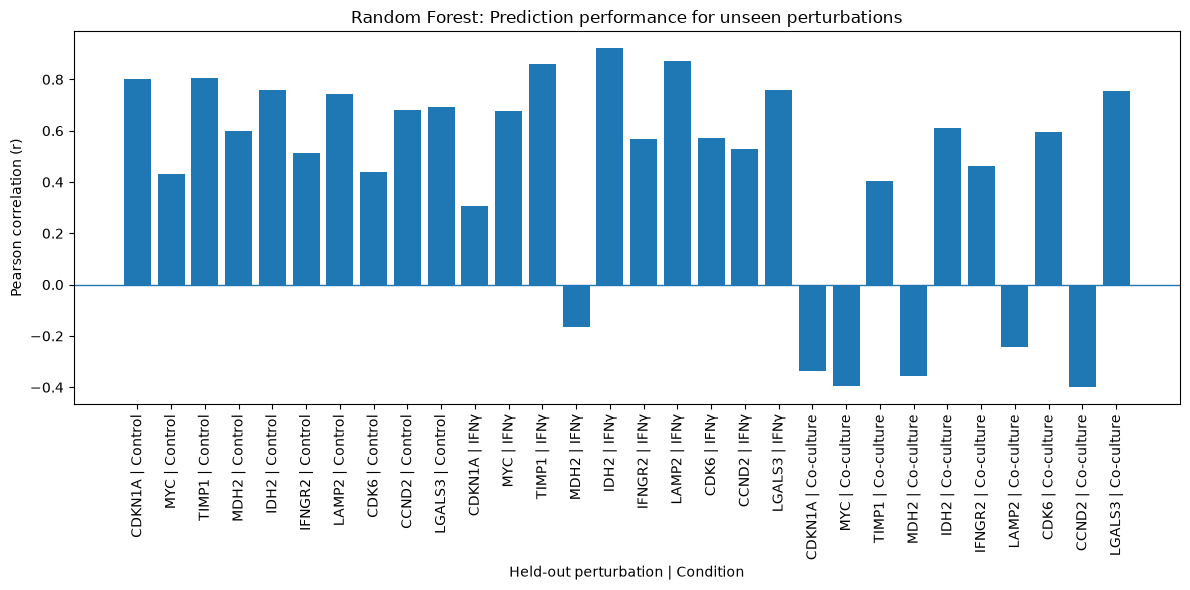

In [105]:

## Visualize Pearson correlations - Model 1 Random Forest

import matplotlib.pyplot as plt

plot_df = results.copy()

labels = (
    plot_df["perturbation"]
    + " | "
    + plot_df["condition"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(plot_df)),
    plot_df["Pearson_r"]
)

plt.xticks(
    range(len(plot_df)),
    labels,
    rotation=90
)

plt.ylabel("Pearson correlation (r)")
plt.xlabel("Held-out perturbation | Condition")

plt.title(
    "Random Forest: Prediction performance for unseen perturbations"
)

plt.axhline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [106]:
# Other method Ridge regression model 
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV

# Use perturbation target as grouping variable
groups = meta_train["perturbation"].values

cv = GroupKFold(n_splits=5)

# Define Ridge hyperparameters
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = Ridge()

search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

search_ridge.fit(
    X_train,
    Y_train_pca,
    groups=groups
)

print("Best Ridge parameters:")
print(search_ridge.best_params_)

Best Ridge parameters:
{'alpha': 100}


In [107]:
# Retrieve the Ridge regression model with the best regularization
# parameter identified during cross-validation
best_ridge = search_ridge.best_estimator_

# Use the optimized Ridge model to predict the 50 PCA components
# of the transcriptomic response for the held-out perturbations
Y_pred_pca_ridge = best_ridge.predict(X_test)

# Transform the predicted PCA components back into the original
# 2,000-gene log2FC space so that they can be directly compared
# with the observed test response profiles
Y_pred_ridge = pca_y.inverse_transform(
    Y_pred_pca_ridge
)

In [108]:
# Calculate the overall Mean Absolute Error (MAE) of the Ridge model
# across all held-out perturbation-condition profiles and response genes
mae_ridge = mean_absolute_error(
    Y_test.ravel(),
    Y_pred_ridge.ravel()
)

# Calculate the overall Root Mean Squared Error (RMSE).
# RMSE penalizes larger prediction errors more strongly than MAE.
rmse_ridge = np.sqrt(
    mean_squared_error(
        Y_test.ravel(),
        Y_pred_ridge.ravel()
    )
)

# Initialize a list to store the Pearson correlation
# for each held-out perturbation-condition profile
pearson_ridge = []

# Loop through all test profiles
for i in range(Y_test.shape[0]):

    # Check that both the observed and predicted profiles
    # contain variation, since Pearson correlation is undefined
    # for constant profiles
    if (
        np.std(Y_test[i]) > 0
        and np.std(Y_pred_ridge[i]) > 0
    ):

        # Calculate the Pearson correlation between the observed
        # and Ridge-predicted log2FC values across the 2,000 response genes
        r, _ = pearsonr(
            Y_test[i],
            Y_pred_ridge[i]
        )

    else:
        # Store NaN if Pearson correlation cannot be calculated
        r = np.nan

    # Store the correlation for the current test profile
    pearson_ridge.append(r)

# Display the overall Ridge prediction errors
print("Ridge MAE:", mae_ridge)
print("Ridge RMSE:", rmse_ridge)

# Display the mean Pearson correlation across all
# held-out perturbation-condition profiles
print(
    "Ridge mean Pearson r:",
    np.nanmean(pearson_ridge)
)

Ridge MAE: 0.023106209160430522
Ridge RMSE: 0.07932393434718815
Ridge mean Pearson r: 0.4434322254611717


In [109]:
# Calculate uncertainty of the Ridge model using
# perturbation-level bootstrap resampling

rng = np.random.default_rng(42)

# Extract the 10 unique held-out perturbation genes
test_gene_names = meta_test["perturbation"].unique()

# Number of bootstrap repetitions
N_BOOTSTRAPS = 1000

bootstrap_mae_ridge = []
bootstrap_rmse_ridge = []
bootstrap_pearson_ridge = []

# Repeat bootstrap resampling 1,000 times
for b in range(N_BOOTSTRAPS):

    # Sample held-out perturbation genes with replacement.
    # All three condition-specific profiles of each perturbation
    # remain together in the bootstrap sample.
    sampled_genes = rng.choice(
        test_gene_names,
        size=len(test_gene_names),
        replace=True
    )

    true_profiles = []
    pred_profiles = []
    correlations = []

    for gene in sampled_genes:

        # Find the three condition-specific profiles
        # belonging to the current perturbation
        idx = np.where(
            meta_test["perturbation"].values == gene
        )[0]

        # Collect observed and Ridge-predicted profiles
        true_profiles.append(
            Y_test[idx]
        )

        pred_profiles.append(
            Y_pred_ridge[idx]
        )

        # Calculate Pearson correlation separately
        # for each condition-specific profile
        for i in idx:

            if (
                np.std(Y_test[i]) > 0
                and np.std(Y_pred_ridge[i]) > 0
            ):

                r, _ = pearsonr(
                    Y_test[i],
                    Y_pred_ridge[i]
                )

                correlations.append(r)

    # Combine all sampled profiles
    true_profiles = np.vstack(
        true_profiles
    )

    pred_profiles = np.vstack(
        pred_profiles
    )

    # Calculate MAE for the current bootstrap sample
    bootstrap_mae_ridge.append(
        mean_absolute_error(
            true_profiles.ravel(),
            pred_profiles.ravel()
        )
    )

    # Calculate RMSE for the current bootstrap sample
    bootstrap_rmse_ridge.append(
        np.sqrt(
            mean_squared_error(
                true_profiles.ravel(),
                pred_profiles.ravel()
            )
        )
    )

    # Calculate mean Pearson correlation
    # for the current bootstrap sample
    bootstrap_pearson_ridge.append(
        np.mean(correlations)
    )

In [110]:
# Calculate 95% bootstrap confidence intervals
mae_ci_ridge = bootstrap_ci(
    bootstrap_mae_ridge
)

rmse_ci_ridge = bootstrap_ci(
    bootstrap_rmse_ridge
)

pearson_ci_ridge = bootstrap_ci(
    bootstrap_pearson_ridge
)

# Display Ridge performance with uncertainty
print("Ridge regression")

print(
    f"MAE: {mae_ridge:.3f} "
    f"[{mae_ci_ridge[0]:.3f}, {mae_ci_ridge[1]:.3f}]"
)

print(
    f"RMSE: {rmse_ridge:.3f} "
    f"[{rmse_ci_ridge[0]:.3f}, {rmse_ci_ridge[1]:.3f}]"
)

print(
    f"Pearson r: {np.nanmean(pearson_ridge):.3f} "
    f"[{pearson_ci_ridge[0]:.3f}, {pearson_ci_ridge[1]:.3f}]"
)

Ridge regression
MAE: 0.023 [0.019, 0.028]
RMSE: 0.079 [0.064, 0.094]
Pearson r: 0.443 [0.287, 0.588]


In [111]:

# Pearson correlation table - Ridge Regression

from scipy.stats import pearsonr
import pandas as pd
import numpy as np

pearson_results_ridge = []

for i in range(len(Y_test)):

    # Pearson correlation across the 2,000 genes
    if (
        np.std(Y_test[i]) > 0
        and np.std(Y_pred_ridge[i]) > 0
    ):
        r, p = pearsonr(
            Y_test[i],
            Y_pred_ridge[i]
        )
    else:
        r = np.nan
        p = np.nan

    pearson_results_ridge.append({
        "perturbation": meta_test.loc[i, "perturbation"],
        "condition": meta_test.loc[i, "condition"],
        "pearson_r": r
    })


# Create dataframe
pearson_df_ridge = pd.DataFrame(
    pearson_results_ridge
)

print(pearson_df_ridge)

   perturbation   condition  pearson_r
0        CDKN1A     Control   0.826181
1           MYC     Control   0.491904
2         TIMP1     Control   0.787085
3          MDH2     Control   0.616580
4          IDH2     Control   0.814184
5        IFNGR2     Control   0.493224
6         LAMP2     Control   0.789106
7          CDK6     Control   0.496295
8         CCND2     Control   0.718159
9        LGALS3     Control   0.701516
10       CDKN1A        IFNγ   0.210407
11          MYC        IFNγ   0.614515
12        TIMP1        IFNγ   0.861049
13         MDH2        IFNγ  -0.171558
14         IDH2        IFNγ   0.915792
15       IFNGR2        IFNγ   0.490612
16        LAMP2        IFNγ   0.842744
17         CDK6        IFNγ   0.574834
18        CCND2        IFNγ   0.498577
19       LGALS3        IFNγ   0.788836
20       CDKN1A  Co-culture  -0.276219
21          MYC  Co-culture  -0.447194
22        TIMP1  Co-culture   0.432926
23         MDH2  Co-culture  -0.352533
24         IDH2  Co-cultu

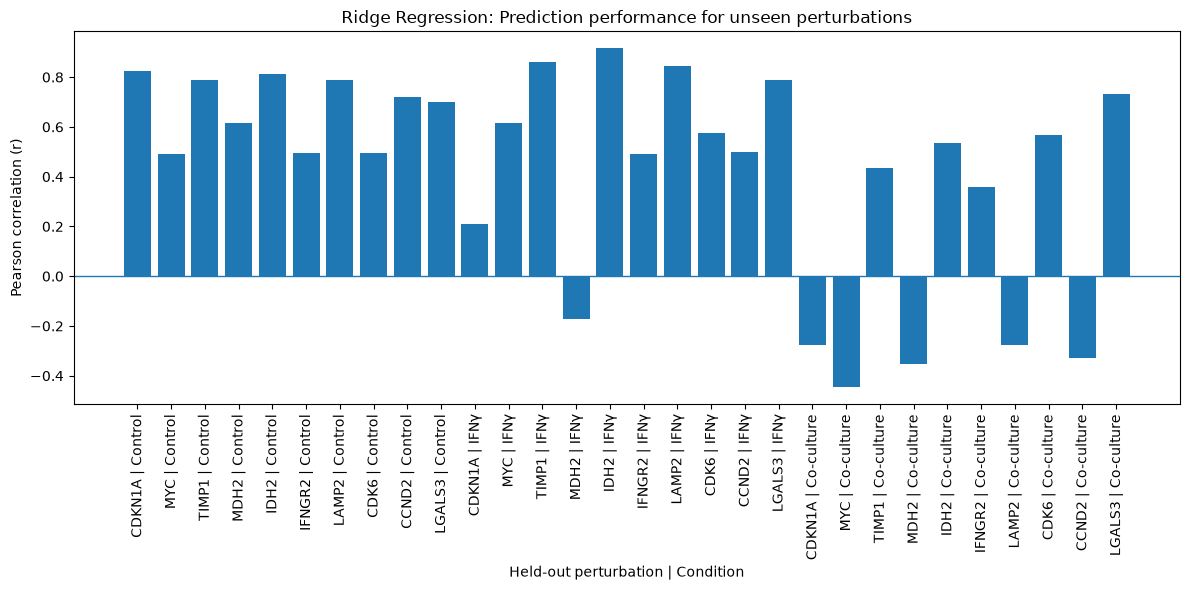

In [112]:
# Pearson correlation plot for predicted conditions 
#Ridge regression
import matplotlib.pyplot as plt

plot_df = pearson_df_ridge.copy()

labels = (
    plot_df["perturbation"]
    + " | "
    + plot_df["condition"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(plot_df)),
    plot_df["pearson_r"]
)

plt.xticks(
    range(len(plot_df)),
    labels,
    rotation=90
)

plt.ylabel("Pearson correlation (r)")
plt.xlabel("Held-out perturbation | Condition")

plt.title(
    "Ridge Regression: Prediction performance for unseen perturbations"
)

plt.axhline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [113]:

# Performance by condition - Ridge Regression

results_ridge = []

for i in range(len(Y_test)):

    y_true = Y_test[i]
    y_pred = Y_pred_ridge[i]

    # MAE for this perturbation-condition profile
    mae_i = mean_absolute_error(
        y_true,
        y_pred
    )

    # RMSE for this perturbation-condition profile
    rmse_i = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # Pearson correlation
    if (
        np.std(y_true) > 0
        and np.std(y_pred) > 0
    ):
        r_i, _ = pearsonr(
            y_true,
            y_pred
        )
    else:
        r_i = np.nan

    results_ridge.append({
        "perturbation": meta_test.loc[i, "perturbation"],
        "condition": meta_test.loc[i, "condition"],
        "MAE": mae_i,
        "RMSE": rmse_i,
        "Pearson_r": r_i
    })


performance_ridge = pd.DataFrame(
    results_ridge
)


# Summarize performance by condition
performance_by_condition_ridge = (
    performance_ridge
    .groupby("condition")[
        ["MAE", "RMSE", "Pearson_r"]
    ]
    .agg(["mean", "std", "median"])
)


print(
    "Ridge Regression - Performance by condition:"
)

print(
    performance_by_condition_ridge
)

Ridge Regression - Performance by condition:
                 MAE                          RMSE                      \
                mean       std    median      mean       std    median   
condition                                                                
Co-culture  0.022771  0.009886  0.017671  0.084267  0.031306  0.077245   
Control     0.023514  0.007366  0.021288  0.066834  0.018959  0.062140   
IFNγ        0.023034  0.009316  0.018741  0.072241  0.031355  0.068288   

           Pearson_r                      
                mean       std    median  
condition                                 
Co-culture  0.094293  0.466239  0.041023  
Control     0.673423  0.138350  0.709837  
IFNγ        0.562581  0.336425  0.594675  


In [114]:
# Different model
# Add control in perturbation column to X as input 
# Input would be the condition, the hallmark annotation and the control as baseline 

In [147]:
#Import pacakages
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import PCA
#Settings
PSEUDOCOUNT = 1
UNPERTURBED_LABEL = "control"
CONDITIONS = ["Control", "IFNγ", "Co-culture"]
PERT_COL = "perturbation"
COND_COL = "condition"
# Number of PCA components used for the baseline expression profile
N_BASELINE_PCS = 50

In [148]:
# Select all unperturbed control cells
baseline_mask_all = (
    adata.obs[PERT_COL]
    .astype(str)
    .str.lower()
    == UNPERTURBED_LABEL.lower()
)

# Keep only the control cells and the selected response genes
baseline_adata_all = adata[
    baseline_mask_all,
    response_genes
].copy()

# Print the total number of control cells
print(
    "Total unperturbed control cells:",
    baseline_adata_all.n_obs
)

# Check how many control cells are present in each condition
print(
    baseline_adata_all.obs[COND_COL].value_counts()
)

Total unperturbed control cells: 50516
condition
IFNγ          20396
Co-culture    17182
Control       12938
Name: count, dtype: int64


In [149]:
# Fit PCA with 50 components to the individual control cells
from sklearn.decomposition import IncrementalPCA

baseline_pca = IncrementalPCA(
    n_components=N_BASELINE_PCS,
    batch_size=2000
)

# Get the expression data of the control cells
X_control = baseline_adata_all.X

# Fit the PCA in batches to reduce memory usage
for start in range(0, baseline_adata_all.n_obs, 2000):

    # Define the end of the current batch
    end = min(
        start + 2000,
        baseline_adata_all.n_obs
    )

    # Select the current batch of cells
    X_batch = X_control[start:end]

    # Convert sparse data to a dense array if necessary
    if sparse.issparse(X_batch):
        X_batch = X_batch.toarray()

    # Fit the PCA on the current batch
    baseline_pca.partial_fit(X_batch)


# Print the number of PCA components
print(
    "Number of baseline PCs:",
    baseline_pca.n_components_
)

# Print how much of the total variance is explained by the 50 PCs
print(
    "Total explained variance:",
    baseline_pca.explained_variance_ratio_.sum()
)

Number of baseline PCs: 50
Total explained variance: 0.9702684082313265


In [150]:
# Transform the control cells into the 50-dimensional PCA space
baseline_scores_batches = []

# Transform the control cells batch by batch
for start in range(0, baseline_adata_all.n_obs, 2000):

    # Define the end of the current batch
    end = min(
        start + 2000,
        baseline_adata_all.n_obs
    )

    # Select the current batch
    X_batch = X_control[start:end]

    # Convert sparse data to a dense array if needed
    if sparse.issparse(X_batch):
        X_batch = X_batch.toarray()

    # Transform the expression data into PCA coordinates
    scores_batch = baseline_pca.transform(
        X_batch
    )

    # Store the PCA scores of the current batch
    baseline_scores_batches.append(
        scores_batch
    )


# Combine the PCA scores from all batches
baseline_scores_all = np.vstack(
    baseline_scores_batches
)

# Check the dimensions of the PCA-transformed control data
print(
    "Baseline PCA scores:",
    baseline_scores_all.shape
)

Baseline PCA scores: (50516, 50)


In [151]:
# Calculate the baseline PC profile for each condition
baseline_pc_profiles = {}

# Get the condition of each control cell
baseline_conditions = (
    baseline_adata_all.obs[COND_COL]
    .astype(str)
    .values
)

# Go through the three experimental conditions
for condition in ["Control", "IFNγ", "Co-culture"]:

    # Select the control cells from the current condition
    condition_mask = (
        baseline_conditions == condition
    )

    # Calculate the mean of the 50 PC values for this condition
    baseline_pc_profiles[condition] = (
        baseline_scores_all[
            condition_mask
        ].mean(axis=0)
    )

    # Print the number of cells and the shape of the baseline profile
    print(
        condition,
        "cells:",
        condition_mask.sum(),
        "baseline PC shape:",
        baseline_pc_profiles[condition].shape
    )

Control cells: 12938 baseline PC shape: (50,)
IFNγ cells: 20396 baseline PC shape: (50,)
Co-culture cells: 17182 baseline PC shape: (50,)


In [152]:
# Build the input matrix X for Model 2
X_rows_model2 = []

# Go through each perturbation-condition profile
for _, row in profile_metadata.iterrows():

    gene = row["perturbation"]
    condition = row["condition"]

    # Add the Hallmark pathway annotations of the perturbed gene
    features = pathway_matrix.loc[
        gene
    ].copy()

    # Add the experimental condition using one-hot encoding
    features["condition_Control"] = int(
        condition == "Control"
    )

    features["condition_IFNγ"] = int(
        condition == "IFNγ"
    )

    features["condition_Co-culture"] = int(
        condition == "Co-culture"
    )

    # Get the unperturbed baseline PC profile
    # corresponding to the same condition
    baseline_vector = (
        baseline_pc_profiles[condition]
    )

    # Add the 50 baseline PCs as additional input features
    for i in range(N_BASELINE_PCS):

        features[
            f"baseline_PC{i+1}"
        ] = baseline_vector[i]

    # Store the features for this profile
    X_rows_model2.append(
        features
    )


# Combine all profiles into the final input matrix
X_model2 = pd.DataFrame(
    X_rows_model2
).reset_index(drop=True)

# Check the dimensions of the input matrix
print(
    "Model 2 X shape:",
    X_model2.shape
)

Model 2 X shape: (150, 103)


In [153]:

# Use the same train/test perturbations as in Model 1

# Select the profiles that belong to the training perturbations
train_mask_model2 = (
    profile_metadata["perturbation"]
    .isin(train_genes)
)

# Select the profiles that belong to the test perturbations
test_mask_model2 = (
    profile_metadata["perturbation"]
    .isin(test_genes)
)


# Create the training and test input data
X_train_model2 = (
    X_model2.loc[
        train_mask_model2
    ]
    .reset_index(drop=True)
)

X_test_model2 = (
    X_model2.loc[
        test_mask_model2
    ]
    .reset_index(drop=True)
)


# Create the training and test target data
Y_train_model2 = Y[
    train_mask_model2.values
]

Y_test_model2 = Y[
    test_mask_model2.values
]

# Keep the matching metadata for training and test profiles
meta_train_model2 = (
    profile_metadata.loc[
        train_mask_model2
    ]
    .reset_index(drop=True)
)

meta_test_model2 = (
    profile_metadata.loc[
        test_mask_model2
    ]
    .reset_index(drop=True)
)
# Check the dimensions of the train and test datasets
print(
    "X_train:",
    X_train_model2.shape
)

print(
    "X_test:",
    X_test_model2.shape
)

print(
    "Y_train:",
    Y_train_model2.shape
)

print(
    "Y_test:",
    Y_test_model2.shape
)

X_train: (120, 103)
X_test: (30, 103)
Y_train: (120, 2000)
Y_test: (30, 2000)


In [154]:
# Apply PCA to the target Y to reduce the 2,000 response genes to 50 components
from sklearn.decomposition import PCA

N_TARGET_PCS = 50

# Create the PCA model with 50 components
pca_y_model2 = PCA(
    n_components=N_TARGET_PCS,
    random_state=42
)

# Fit the PCA only on the training data and transform it
Y_train_pca_model2 = (
    pca_y_model2.fit_transform(
        Y_train_model2
    )
)

# Transform the test data using the PCA fitted on the training data
Y_test_pca_model2 = (
    pca_y_model2.transform(
        Y_test_model2
    )
)

# Check the dimensions after PCA
print(
    "Y train PCA shape:",
    Y_train_pca_model2.shape
)

print(
    "Y test PCA shape:",
    Y_test_pca_model2.shape
)

# Check how much of the variance is explained by the 50 PCs
print(
    "Explained variance:",
    pca_y_model2
    .explained_variance_ratio_
    .sum()
)

Y train PCA shape: (120, 50)
Y test PCA shape: (30, 50)
Explained variance: 0.92439425


In [155]:
# Train the Random Forest for Model 2 

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import numpy as np

# Create groups based on perturbation identity
train_groups_model2 = meta_train_model2["perturbation"].values

# Check that groups match the number of training samples
assert len(train_groups_model2) == X_train_model2.shape[0]


# Initialize the Random Forest
rf_model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


# Define the hyperparameter search space
param_dist = {

    # Number of trees in the forest
    "n_estimators": [100, 200, 300, 400],

    # Maximum depth of each tree
    "max_depth": [3, 6, 9, 12, None],

    # Minimum number of samples required to split a node
    "min_samples_split": [2, 4, 6, 8],

    # Minimum number of samples required in a leaf
    "min_samples_leaf": [1, 2, 3, 4],

    # Number or proportion of features considered at each split
    "max_features": ["sqrt", "log2", 0.5, 1.0]
}


# Grouped cross-validation by perturbation
cv = GroupKFold(n_splits=5)


# Perform randomized hyperparameter search
random_search_model2 = RandomizedSearchCV(
    estimator=rf_model2,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Train and search for the best hyperparameters
random_search_model2.fit(
    X_train_model2,
    Y_train_pca_model2,
    groups=train_groups_model2
)


# Get the best fitted Model 2
best_rf_model2 = random_search_model2.best_estimator_

print("Best parameters for Model 2:")
print(random_search_model2.best_params_)

print("Best CV MSE:")
print(-random_search_model2.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ubuntu/miniforge/envs/denbi/lib/py

Best parameters for Model 2:
{'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 9}
Best CV MSE:
0.16569840635949554


In [156]:
# Predict unseen perturbations using the best Model 2
Y_pred_pca_model2 = best_rf_model2.predict(
    X_test_model2
)

# Transform predictions back from PCA space to gene-expression space
Y_pred_model2 = pca_y_model2.inverse_transform(
    Y_pred_pca_model2
)

print(
    "Prediction shape:",
    Y_pred_model2.shape
)

Prediction shape: (30, 2000)


In [157]:
# Evaluate the performance of Model 2 separately for each condition
condition_results = []

# Go through the three experimental conditions
for condition in ["Control", "IFNγ", "Co-culture"]:

    # Select the test profiles from the current condition
    mask = (
        meta_test_model2["condition"]
        == condition
    ).values

    # Get the true and predicted responses for this condition
    y_true_cond = Y_test_model2[mask]
    y_pred_cond = Y_pred_model2[mask]

    # Calculate the MAE for this condition
    mae_cond = mean_absolute_error(
        y_true_cond,
        y_pred_cond
    )

    # Calculate the RMSE for this condition
    rmse_cond = np.sqrt(
        mean_squared_error(
            y_true_cond,
            y_pred_cond
        )
    )

    # Calculate Pearson correlation for each perturbation profile
    correlations = []

    for i in range(len(y_true_cond)):

        r, _ = pearsonr(
            y_true_cond[i],
            y_pred_cond[i]
        )

        correlations.append(r)

    # Store the performance metrics for this condition
    condition_results.append({
        "condition": condition,
        "MAE": mae_cond,
        "RMSE": rmse_cond,
        "Mean_Pearson_r": np.mean(correlations)
    })


# Create a table with the performance for each condition
condition_metrics_model2 = pd.DataFrame(
    condition_results
)

# Display the results
print(condition_metrics_model2)

    condition       MAE      RMSE  Mean_Pearson_r
0     Control  0.024207  0.071635        0.648175
1        IFNγ  0.022582  0.076394        0.591507
2  Co-culture  0.022556  0.086428        0.103550


In [158]:
# Evaluate Model 2 separately for each unseen perturbation
perturbation_results = []

# Go through the 10 perturbations in the test set
for pert in test_genes:

    # Select the test profiles belonging to this perturbation
    mask = (
        meta_test_model2["perturbation"]
        == pert
    ).values

    # Get the true and predicted responses for this perturbation
    y_true_pert = Y_test_model2[mask]
    y_pred_pert = Y_pred_model2[mask]

    # Calculate the MAE
    mae_pert = mean_absolute_error(
        y_true_pert,
        y_pred_pert
    )

    # Calculate the RMSE
    rmse_pert = np.sqrt(
        mean_squared_error(
            y_true_pert,
            y_pred_pert
        )
    )

    # Calculate Pearson correlation for each condition
    correlations = []

    for i in range(len(y_true_pert)):

        r, _ = pearsonr(
            y_true_pert[i],
            y_pred_pert[i]
        )

        correlations.append(r)

    # Store the average performance across the three conditions
    perturbation_results.append({
        "perturbation": pert,
        "MAE": mae_pert,
        "RMSE": rmse_pert,
        "Mean_Pearson_r": np.mean(correlations)
    })


# Create a table with the results for each unseen perturbation
# and sort the perturbations by their mean Pearson correlation
perturbation_metrics_model2 = pd.DataFrame(
    perturbation_results
).sort_values(
    "Mean_Pearson_r",
    ascending=False
)

# Display the results
print(perturbation_metrics_model2)

  perturbation       MAE      RMSE  Mean_Pearson_r
3         IDH2  0.016595  0.047942        0.765431
9       LGALS3  0.019255  0.054867        0.732497
2        TIMP1  0.019452  0.056734        0.691032
5         CDK6  0.037441  0.101131        0.524212
7       IFNGR2  0.030751  0.117442        0.511218
6        LAMP2  0.015199  0.053299        0.456095
8        CCND2  0.017813  0.063349        0.266463
1       CDKN1A  0.018216  0.068497        0.265798
0          MYC  0.034507  0.105447        0.240433
4         MDH2  0.021921  0.079029        0.024262


In [159]:
from scipy.stats import pearsonr

# Create a table for Pearson correlations
pearson_df_model2 = meta_test_model2.copy()

# Calculate Pearson correlation for each test profile
pearson_df_model2["pearson_r"] = [
    pearsonr(
        Y_test_model2[i],
        Y_pred_model2[i]
    )[0]
    for i in range(len(Y_test_model2))
]

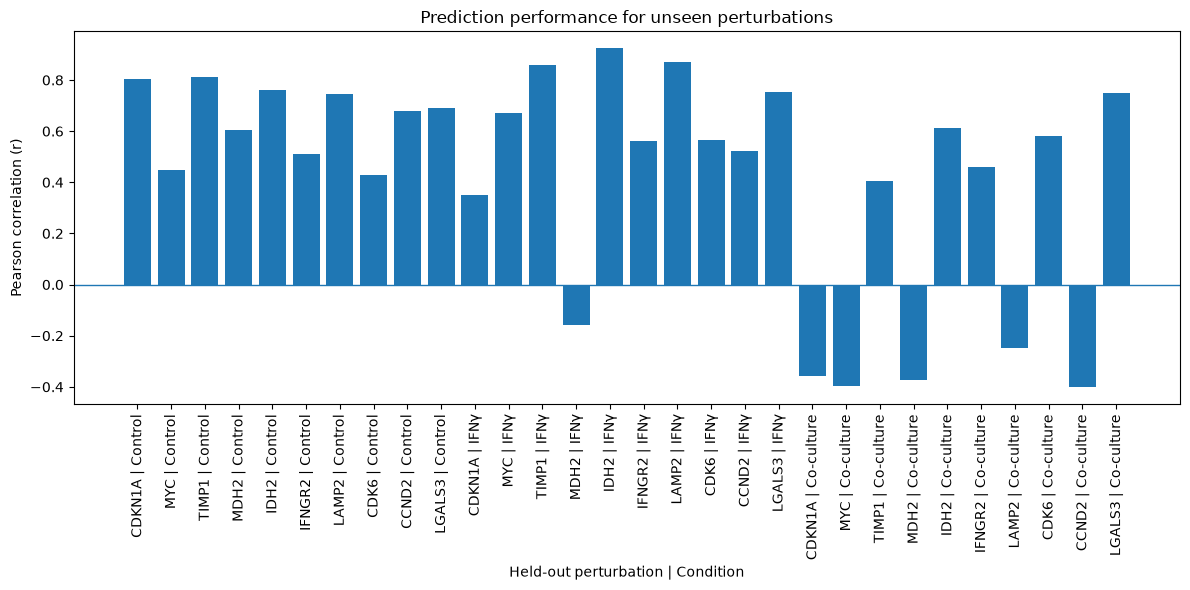

In [160]:

# Visualize the Pearson correlation for each unseen perturbation and condition

import matplotlib.pyplot as plt

# Copy the Pearson correlation results from Model 2
plot_df = pearson_df_model2.copy()

# Create labels containing the perturbation and condition
labels = (
    plot_df["perturbation"]
    + " | "
    + plot_df["condition"]
)

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the Pearson correlation of each test profile
plt.bar(
    range(len(plot_df)),
    plot_df["pearson_r"]
)

# Add perturbation and condition names to the x-axis
plt.xticks(
    range(len(plot_df)),
    labels,
    rotation=90
)

# Add axis labels
plt.ylabel("Pearson correlation (r)")
plt.xlabel("Held-out perturbation | Condition")

# Add a title
plt.title(
    "Prediction performance for unseen perturbations"
)

# Add a horizontal line at zero
plt.axhline(
    0,
    linewidth=1
)

# Show the layout
plt.tight_layout()
plt.show()

In [161]:
# Evaluate the performance of Random Forest Model 2 for each test profile

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

results_model2 = []

# Go through all perturbation-condition profiles in the test set
for i in range(len(Y_test_model2)):

    # Get the true and predicted gene expression response
    y_true = Y_test_model2[i]
    y_pred = Y_pred_model2[i]

    # Calculate MAE for this profile
    mae_i = mean_absolute_error(
        y_true,
        y_pred
    )

    # Calculate RMSE for this profile
    rmse_i = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # Calculate Pearson correlation for this profile
    if (
        np.std(y_true) > 0
        and np.std(y_pred) > 0
    ):
        r_i, _ = pearsonr(
            y_true,
            y_pred
        )
    else:
        r_i = np.nan

    # Store the results together with the perturbation and condition
    results_model2.append({
        "perturbation": meta_test_model2.loc[i, "perturbation"],
        "condition": meta_test_model2.loc[i, "condition"],
        "MAE": mae_i,
        "RMSE": rmse_i,
        "Pearson_r": r_i
    })


# Create a dataframe with the results for all test profiles
performance_model2 = pd.DataFrame(
    results_model2
)


# Group the results by experimental condition
# and calculate the mean, standard deviation and median
performance_by_condition_model2 = (
    performance_model2
    .groupby("condition")[
        ["MAE", "RMSE", "Pearson_r"]
    ]
    .agg(["mean", "std", "median"])
)


# Display the performance for each condition
print(
    "Random Forest Model 2 - Performance by condition:"
)

print(
    performance_by_condition_model2
)

Random Forest Model 2 - Performance by condition:
                 MAE                          RMSE                      \
                mean       std    median      mean       std    median   
condition                                                                
Co-culture  0.022556  0.009858  0.017816  0.081133  0.031399  0.071929   
Control     0.024207  0.007616  0.021502  0.069283  0.019192  0.063619   
IFNγ        0.022582  0.009002  0.019443  0.070509  0.030993  0.064327   

           Pearson_r                      
                mean       std    median  
condition                                 
Co-culture  0.103550  0.493714  0.078443  
Control     0.648175  0.143223  0.686185  
IFNγ        0.591507  0.319663  0.617094  


In [162]:
# Calculate the overall performance of Random Forest Model 2

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr


# Calculate the overall mean absolute error
mae_model2 = mean_absolute_error(
    Y_test_model2,
    Y_pred_model2
)

# Calculate the overall root mean squared error
rmse_model2 = np.sqrt(
    mean_squared_error(
        Y_test_model2,
        Y_pred_model2
    )
)

# Calculate the Pearson correlation for each
# perturbation-condition profile
pearson_model2 = []

for i in range(len(Y_test_model2)):

    # Check that both profiles have variation
    if (
        np.std(Y_test_model2[i]) > 0
        and np.std(Y_pred_model2[i]) > 0
    ):

        # Compare the true and predicted response
        # across the 2,000 genes
        r, _ = pearsonr(
            Y_test_model2[i],
            Y_pred_model2[i]
        )

        # Store the correlation
        pearson_model2.append(r)


# Calculate the mean Pearson correlation
# across all test profiles
mean_pearson_model2 = np.mean(
    pearson_model2
)


# Print the overall performance
print("Random Forest Model 2")
print("MAE:", mae_model2)
print("RMSE:", rmse_model2)
print("Mean Pearson r:", mean_pearson_model2)

Random Forest Model 2
MAE: 0.023114870717824573
RMSE: 0.07839528387194981
Mean Pearson r: 0.4477441411102641


In [163]:
# Estimate the uncertainty of Model 2 using bootstrap confidence intervals

# Number of bootstrap repetitions
N_BOOTSTRAPS = 1000

# Set a random seed so the results are reproducible
rng = np.random.default_rng(42)

# Get the 10 unique unseen perturbations from the test set
unique_test_perts = (
    meta_test_model2["perturbation"]
    .unique()
)

# Create lists to store the performance from each bootstrap sample
bootstrap_mae = []
bootstrap_rmse = []
bootstrap_pearson = []


# Repeat the bootstrap 1000 times
for b in range(N_BOOTSTRAPS):

    # Randomly sample the held-out perturbations with replacement
    sampled_perts = rng.choice(
        unique_test_perts,
        size=len(unique_test_perts),
        replace=True
    )

    true_profiles = []
    pred_profiles = []

    # Collect the three condition profiles for each sampled perturbation
    for pert in sampled_perts:

        # Select all test profiles belonging to this perturbation
        mask = (
            meta_test_model2["perturbation"]
            == pert
        ).values

        # Store the true responses
        true_profiles.append(
            Y_test_model2[mask]
        )

        # Store the predicted responses
        pred_profiles.append(
            Y_pred_model2[mask]
        )

    # Combine the sampled true profiles
    y_true_boot = np.vstack(
        true_profiles
    )

    # Combine the sampled predicted profiles
    y_pred_boot = np.vstack(
        pred_profiles
    )

    # Calculate MAE for this bootstrap sample
    bootstrap_mae.append(
        mean_absolute_error(
            y_true_boot,
            y_pred_boot
        )
    )

    # Calculate RMSE for this bootstrap sample
    bootstrap_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_true_boot,
                y_pred_boot
            )
        )
    )

    # Calculate Pearson correlation for each profile
    r_values = []

    for i in range(len(y_true_boot)):

        # Check that both profiles have variation
        if (
            np.std(y_true_boot[i]) > 0
            and np.std(y_pred_boot[i]) > 0
        ):

            # Calculate the correlation between the true
            # and predicted response across the 2,000 genes
            r, _ = pearsonr(
                y_true_boot[i],
                y_pred_boot[i]
            )

            r_values.append(r)

    # Store the mean Pearson correlation of this bootstrap sample
    bootstrap_pearson.append(
        np.mean(r_values)
    )

In [164]:
# Calculate the 95% confidence intervals from the bootstrap results

# Get the lower and upper 95% confidence limits for MAE
mae_ci = np.percentile(
    bootstrap_mae,
    [2.5, 97.5]
)

# Get the lower and upper 95% confidence limits for RMSE
rmse_ci = np.percentile(
    bootstrap_rmse,
    [2.5, 97.5]
)

# Get the lower and upper 95% confidence limits for Pearson correlation
pearson_ci = np.percentile(
    bootstrap_pearson,
    [2.5, 97.5]
)


# Print the overall performance together with the 95% confidence intervals
print("Random Forest Model 2")

print(
    f"MAE: {mae_model2:.3f} "
    f"[{mae_ci[0]:.3f}, {mae_ci[1]:.3f}]"
)

print(
    f"RMSE: {rmse_model2:.3f} "
    f"[{rmse_ci[0]:.3f}, {rmse_ci[1]:.3f}]"
)

print(
    f"Pearson r: {mean_pearson_model2:.3f} "
    f"[{pearson_ci[0]:.3f}, {pearson_ci[1]:.3f}]"
)

Random Forest Model 2
MAE: 0.023 [0.019, 0.028]
RMSE: 0.078 [0.063, 0.093]
Pearson r: 0.448 [0.289, 0.594]


In [ ]:
# Model 2: Ridge Regression same features 

In [167]:

# Create Ridge Regression model
ridge_model2 = Ridge()
# Define regularization strengths to test
param_grid_ridge_model2 = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0
    ]
}
# Use the same grouped cross-validation strategy as Model 2 Random Forest
cv_ridge_model2 = GroupKFold(
    n_splits=5
)
# Use the actual perturbation identity of each training profile
groups_ridge_model2 = meta_train_model2[
    "perturbation"
].values

# Search for the best Ridge regularization parameter
ridge_search_model2 = GridSearchCV(
    estimator=ridge_model2,
    param_grid=param_grid_ridge_model2,
    scoring="neg_mean_squared_error",
    cv=cv_ridge_model2,
    n_jobs=-1
)
# Train Ridge using the same Model 2 features
# and the same PCA-transformed transcriptomic response
ridge_search_model2.fit(
    X_train_model2,
    Y_train_pca_model2,
    groups=groups_ridge_model2
)


# Retrieve the best Ridge model
best_ridge_model2 = ridge_search_model2.best_estimator_

print(
    "Best Ridge alpha:",
    ridge_search_model2.best_params_
)

print(
    "Best Ridge CV MSE:",
    -ridge_search_model2.best_score_
)

Best Ridge alpha: {'alpha': 1000.0}
Best Ridge CV MSE: 0.16634747159615249


In [168]:
# Predict the PCA components of the held-out perturbations
Y_pred_pca_ridge_model2 = best_ridge_model2.predict(
    X_test_model2
)


# Transform predictions back into the original
# 2,000-gene log2FC response space
Y_pred_ridge_model2 = pca_y_model2.inverse_transform(
    Y_pred_pca_ridge_model2
)

print(
    "Prediction shape:",
    Y_pred_ridge_model2.shape
)

Prediction shape: (30, 2000)


In [169]:
#Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from scipy.stats import pearsonr


# Calculate overall MAE
mae_ridge_model2 = mean_absolute_error(
    Y_test_model2.ravel(),
    Y_pred_ridge_model2.ravel()
)


# Calculate overall RMSE
rmse_ridge_model2 = np.sqrt(
    mean_squared_error(
        Y_test_model2.ravel(),
        Y_pred_ridge_model2.ravel()
    )
)


# Calculate Pearson correlation for each test profile
pearson_ridge_model2 = []

for i in range(len(Y_test_model2)):

    r, _ = pearsonr(
        Y_test_model2[i],
        Y_pred_ridge_model2[i]
    )

    pearson_ridge_model2.append(r)


# Calculate mean Pearson correlation
mean_pearson_ridge_model2 = np.mean(
    pearson_ridge_model2
)


print("Ridge Model 2 MAE:", mae_ridge_model2)
print("Ridge Model 2 RMSE:", rmse_ridge_model2)
print(
    "Ridge Model 2 Mean Pearson r:",
    mean_pearson_ridge_model2
)

Ridge Model 2 MAE: 0.023059526510017105
Ridge Model 2 RMSE: 0.07910198339765993
Ridge Model 2 Mean Pearson r: 0.43492734047633513


In [170]:

# 95% BOOTSTRAP CONFIDENCE INTERVALS - RIDGE MODEL 2
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr


# Number of bootstrap repetitions
N_BOOTSTRAP = 1000

# Random number generator for reproducibility
rng = np.random.default_rng(42)

# Get the unique held-out perturbations
test_perturbations = meta_test_model2[
    "perturbation"
].unique()


# Store bootstrap results
bootstrap_mae = []
bootstrap_rmse = []
bootstrap_pearson = []


# Perform bootstrap
for _ in range(N_BOOTSTRAP):

    # Sample held-out perturbations with replacement
    sampled_perturbations = rng.choice(
        test_perturbations,
        size=len(test_perturbations),
        replace=True
    )

    # Collect the corresponding profile indices
    sampled_indices = []

    for perturbation in sampled_perturbations:

        indices = np.where(
            meta_test_model2["perturbation"].values
            == perturbation
        )[0]

        sampled_indices.extend(indices)

    sampled_indices = np.array(sampled_indices)


    # Select true and predicted profiles
    y_true_boot = Y_test_model2[
        sampled_indices
    ]

    y_pred_boot = Y_pred_ridge_model2[
        sampled_indices
    ]


    # Bootstrap MAE
    bootstrap_mae.append(
        mean_absolute_error(
            y_true_boot.ravel(),
            y_pred_boot.ravel()
        )
    )


    # Bootstrap RMSE
    bootstrap_rmse.append(
        np.sqrt(
            mean_squared_error(
                y_true_boot.ravel(),
                y_pred_boot.ravel()
            )
        )
    )


    # Pearson correlation for each sampled profile
    correlations = []

    for i in range(len(y_true_boot)):

        r, _ = pearsonr(
            y_true_boot[i],
            y_pred_boot[i]
        )

        correlations.append(r)


    bootstrap_pearson.append(
        np.mean(correlations)
    )


# Calculate 95% confidence intervals
mae_ci = np.percentile(
    bootstrap_mae,
    [2.5, 97.5]
)

rmse_ci = np.percentile(
    bootstrap_rmse,
    [2.5, 97.5]
)

pearson_ci = np.percentile(
    bootstrap_pearson,
    [2.5, 97.5]
)


# Display results
print(
    "MAE 95% CI:",
    mae_ci
)

print(
    "RMSE 95% CI:",
    rmse_ci
)

print(
    "Mean Pearson r 95% CI:",
    pearson_ci
)

MAE 95% CI: [0.01885005 0.0282097 ]
RMSE 95% CI: [0.06304282 0.09465149]
Mean Pearson r 95% CI: [0.27819373 0.58321275]


In [171]:
# Calculate Pearson correlation for each unseen perturbation-condition profile
pearson_df_ridge_model2 = meta_test_model2.copy()

pearson_df_ridge_model2["pearson_r"] = [
    pearsonr(
        Y_test_model2[i],
        Y_pred_ridge_model2[i]
    )[0]
    for i in range(len(Y_test_model2))
]

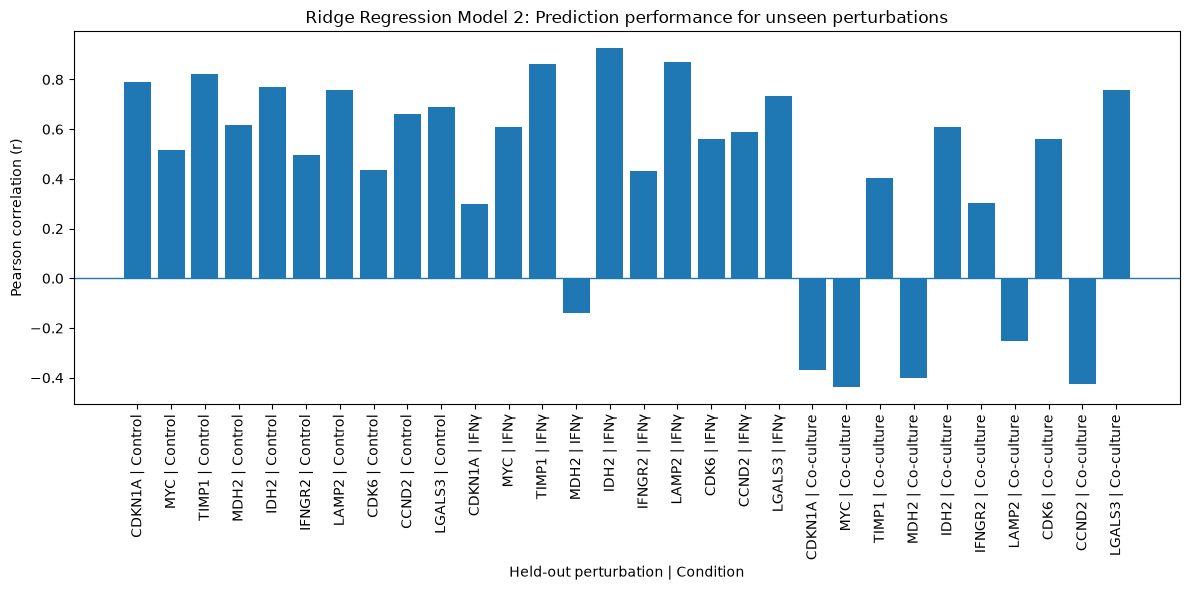

In [172]:
# Pearson correlation plot for Ridge Model 2
import matplotlib.pyplot as plt

plot_df = pearson_df_ridge_model2.copy()

labels = (
    plot_df["perturbation"]
    + " | "
    + plot_df["condition"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(plot_df)),
    plot_df["pearson_r"]
)

plt.xticks(
    range(len(plot_df)),
    labels,
    rotation=90
)

plt.ylabel("Pearson correlation (r)")
plt.xlabel("Held-out perturbation | Condition")

plt.title(
    "Ridge Regression Model 2: Prediction performance for unseen perturbations"
)

plt.axhline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [173]:
# Create performance table for each test profile
results_ridge_model2 = meta_test_model2.copy()

results_ridge_model2["MAE"] = [
    mean_absolute_error(
        Y_test_model2[i],
        Y_pred_ridge_model2[i]
    )
    for i in range(len(Y_test_model2))
]

results_ridge_model2["RMSE"] = [
    np.sqrt(
        mean_squared_error(
            Y_test_model2[i],
            Y_pred_ridge_model2[i]
        )
    )
    for i in range(len(Y_test_model2))
]

results_ridge_model2["Pearson_r"] = [
    pearsonr(
        Y_test_model2[i],
        Y_pred_ridge_model2[i]
    )[0]
    for i in range(len(Y_test_model2))
]

In [174]:
# Performance by condition for Ridge Regression Model 2
condition_results_ridge_model2 = (
    results_ridge_model2
    .groupby("condition")
    [["MAE", "RMSE", "Pearson_r"]]
    .agg(["mean", "std", "median"])
)

print("\nRidge Model 2 - Performance by condition:")
print(condition_results_ridge_model2)


Ridge Model 2 - Performance by condition:
                 MAE                          RMSE                      \
                mean       std    median      mean       std    median   
condition                                                                
Co-culture  0.022787  0.010311  0.017556  0.082004  0.032889  0.072828   
Control     0.023760  0.007233  0.021277  0.068167  0.018329  0.063044   
IFNγ        0.022632  0.009753  0.019247  0.071618  0.033249  0.066834   

           Pearson_r                      
                mean       std    median  
condition                                 
Co-culture  0.074767  0.493799  0.025094  
Control     0.655554  0.135111  0.676849  
IFNγ        0.574461  0.321081  0.599700  


In [165]:
# GEARS model
#Three different models are trained
#GEARS for control, GEARS for IFNG condition and GEARS for coculture condition

In [166]:
import os
import pickle
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from gears import PertData, GEARS
#Settings
GEARS_DATA_DIR = "../data/gears"
os.makedirs(GEARS_DATA_DIR, exist_ok=True)
CURRENT_CONDITION = "Control" # first GEARS for control condition
PERT_COL = "perturbation"
COND_COL = "condition"
UNPERTURBED_LABEL = "control"
# train_genes and test_genes are already defined earlier
print("Train perturbations:", len(train_genes))
print("Test perturbations:", len(test_genes))

ModuleNotFoundError: No module named 'torch'

In [ ]:
#Subset to control as experimental condition
adata_gears = adata[
    adata.obs[COND_COL] == CURRENT_CONDITION
].copy()

print(
    CURRENT_CONDITION,
    "cells:",
    adata_gears.n_obs
)

In [ ]:
# ============================================================
# 3. FORMAT AnnData FOR GEARS
# ============================================================

# GEARS expects gene names here
adata_gears.var["gene_name"] = adata_gears.var_names.astype(str)

# GEARS expects the perturbation identity in obs["condition"]
adata_gears.obs["condition"] = (
    adata_gears.obs[PERT_COL]
    .astype(str)
)

# GEARS also expects cell_type
# Since we train one model per experimental condition,
# all cells in this object belong to the same context
adata_gears.obs["cell_type"] = CURRENT_CONDITION

In [ ]:
# ============================================================
# 4. CREATE GEARS PertData OBJECT
# ============================================================

pert_data = PertData(GEARS_DATA_DIR)

dataset_name = f"frangieh_{CURRENT_CONDITION.lower()}"

pert_data.new_data_process(
    dataset_name=dataset_name,
    adata=adata_gears
)

In [ ]:
# ============================================================
# 5. CREATE CUSTOM TRAIN / TEST SPLIT
# ============================================================

gears_train_genes = list(train_genes)
gears_test_genes = list(test_genes)

print("GEARS train genes:", len(gears_train_genes))  # 40
print("GEARS test genes:", len(gears_test_genes))    # 10
# ============================================================
# 5. CREATE TRAIN / VALIDATION / TEST SPLIT FOR GEARS
# ============================================================

rng = np.random.default_rng(42)

# Same 40 development genes and 10 held-out test genes
development_genes = np.array(train_genes)
gears_test_genes = list(test_genes)

# Split the 40 development genes into 32 train + 8 validation
rng.shuffle(development_genes)

n_val = 8

gears_val_genes = development_genes[:n_val].tolist()
gears_train_genes = development_genes[n_val:].tolist()

print("GEARS training genes:", len(gears_train_genes))
print("GEARS validation genes:", len(gears_val_genes))
print("GEARS test genes:", len(gears_test_genes))


In [ ]:
# ============================================================
# 6. CREATE CUSTOM GEARS SPLIT
# ============================================================

custom_split = {
    "train": gears_train_genes + [UNPERTURBED_LABEL],
    "val": gears_val_genes + [UNPERTURBED_LABEL],
    "test": gears_test_genes
}

split_path = os.path.join(
    GEARS_DATA_DIR,
    f"{dataset_name}_custom_split.pkl"
)

with open(split_path, "wb") as f:
    pickle.dump(custom_split, f)


In [ ]:
# 7. PREPARE SPLIT AND DATALOADERS
# ============================================================

pert_data.prepare_split(
    split="custom",
    split_dict_path=split_path
)

pert_data.get_dataloader(
    batch_size=32,
    test_batch_size=128
)


# ============================================================
# 8. INITIALIZE GEARS MODEL
# ============================================================

device = "cuda:0" if torch.cuda.is_available() else "cpu"

gears_model = GEARS(
    pert_data,
    device=device
)

gears_model.model_initialize(
    hidden_size=64
)





# ============================================================
# 11. PREDICT THE 10 HELD-OUT PERTURBATIONS
# ============================================================

prediction_queries = [
    [gene] for gene in gears_test_genes
]

predictions = gears_model.predict(
    prediction_queries
)